# Photometry of M16
## Section 1: Importing Modules and Libraries

In [10]:
#import packages 
%matplotlib widget
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.time import Time
import astropy.units as u
import urllib.request
import os
import gzip
import shutil
from astropy.io import fits
from astropy.utils.data import download_file
from astropy.visualization import astropy_mpl_style
from astropy.stats import sigma_clipped_stats 
import photutils
from photutils.detection import DAOStarFinder
from photutils.aperture import CircularAperture
from astropy.visualization import ZScaleInterval, AsinhStretch, ImageNormalize
from astropy.nddata.utils import Cutout2D
from scipy.optimize import curve_fit


## Section 2: Downloading the FITS Image of M16

In [2]:

m16_url = "https://mast.stsci.edu/api/v0.1/Download/file/?uri=mast:HST/product/idnm29ytq_drz.fits" #URL of M16 image from the MAST Archive 
m16_file = download_file(m16_url, cache = True)
m16_file 
#"https://opencomputinglab.github.io/SubjectMatterNotebooks/astronomy/fits-images.html"

'C:\\Users\\mya\\.astropy\\cache\\download\\url\\f8cf98df576c56953cbeb544353cc99a\\contents'

In [3]:
m16_hdu_list = fits.open(m16_file) 
if 'm16.fits' not in os.listdir():
    m16_hdu_list.writeto('m16.fits')

m16_data = fits.getdata('m16.fits')

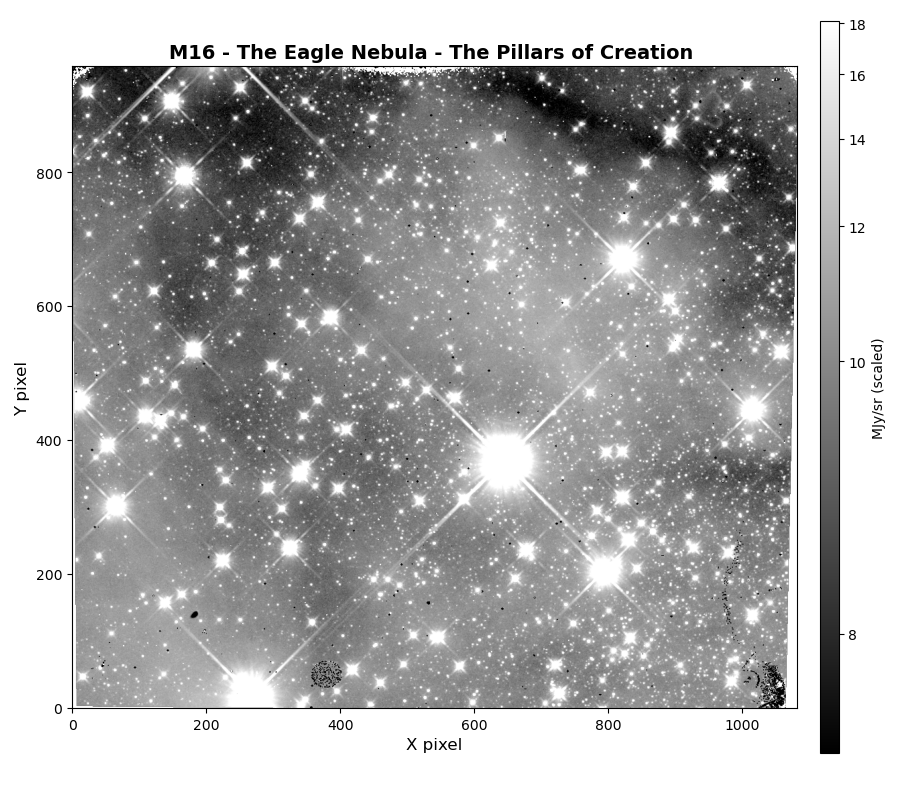

In [8]:
if os.path.exists(m16_file) and m16_data is not None:
    
    # Combine interval (ZScale finds optimal min/max) with stretch (AsinhStretch compresses dynamic range)
    norm = ImageNormalize(m16_data, 
                          interval=ZScaleInterval(),
                          stretch=AsinhStretch())
    
    # Calculate figure size maintaining aspect ratio
    aspect_ratio = m16_data.shape[0] / m16_data.shape[1]
    fig_width = 9
    fig_height = fig_width * aspect_ratio
    
    plt.figure(figsize=(fig_width, fig_height))
    
    # origin='lower' puts (0,0) at bottom-left (astronomical convention)
    plt.imshow(m16_data, cmap='gray', origin='lower', norm=norm)
    plt.colorbar(label='MJy/sr (scaled)', fraction=0.03, pad=0.03, aspect=40)
    plt.title('M16 - The Eagle Nebula - The Pillars of Creation ', 
              fontsize=14, fontweight='bold')
    plt.xlabel('X pixel', fontsize=12)
    plt.ylabel('Y pixel', fontsize=12)
    plt.tight_layout()
    plt.show()
elif os.path.exists(m16_file):
    print("Skipping visualization - no image data loaded")

9.960842 9.955563 1.1637075


id,x_centroid,y_centroid,sharpness,roundness1,roundness2,n_pixels,peak,flux,mag,daofind_mag
int64,float64,float64,float64,float32,float64,int64,float32,float32,float32,float64
1,513.9031613130381,0.24899927410070835,0.7134274434016479,0.73040944,0.645589082323234,25,6.990198,5.0858507,-1.7659091,-0.32525072576141817
2,531.244923398953,0.7242084156717052,0.5570064105140807,-0.5596071,-0.4302496129471298,25,6.4244003,33.142887,-3.800976,-0.0630726861460992
3,640.3802391165789,1.507574418006386,0.6470048232320408,0.673943,0.12822422128700103,25,13.354204,69.563126,-4.6059475,-0.7253815941500346
4,689.880822165965,2.1507383678415763,0.7034356503292205,-0.07083377,-0.06521381944696207,25,7.1584435,32.006096,-3.7630818,-0.038558766333971733
5,889.1285480685689,1.6852632918270505,0.600553106129291,0.1733785,0.05131582371828351,25,7.8709087,46.877056,-4.1774006,-0.18219432394207313
6,1000.5139633724588,1.667521948390524,0.6897895149235104,-0.5610327,-0.3384302375249362,25,14.733271,84.8105,-4.821124,-0.7314249550216299
7,341.4690704170448,4.089008725377353,0.6978766835594474,-0.16265784,-0.07101482391511271,25,2963.7134,13537.954,-10.328883,-6.570118288198742
8,717.8394981175869,4.186415498954901,0.6496538023839602,-0.69771636,-0.17126609028904435,25,64.53616,353.8478,-6.372041,-2.4174489455072092
9,726.5364657641597,4.4396614590810115,0.5265484142955668,0.39196274,-0.21315151654697473,25,130.2923,811.4805,-7.2731953,-3.3073912703625776


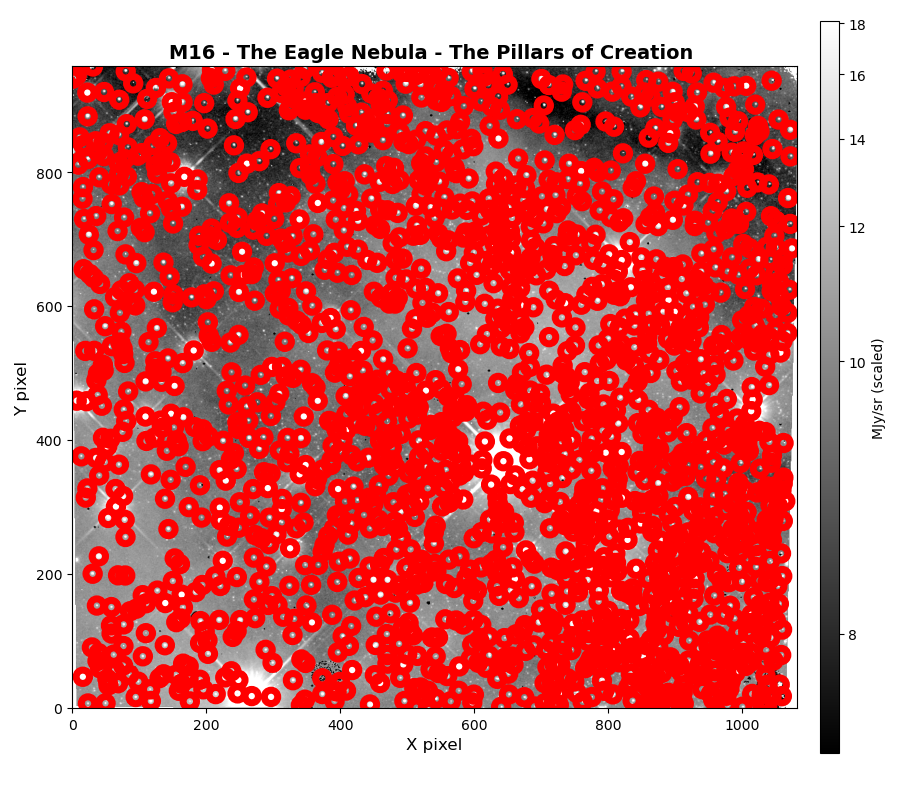

In [51]:

mean,median,std=sigma_clipped_stats(m16_data, sigma=3.0)
print(mean,median,std)

daofind=DAOStarFinder(fwhm=3.0,threshold=5*std)
# find sources
sources=daofind(m16_data-median)
display(sources)


 #code from DESI ASTRO 
positions = np.transpose((sources['xcentroid'],sources['ycentroid']))
plt.figure(figsize=(fig_width, fig_height))
apertures=CircularAperture(positions,r=10)
apertures.plot(color='red',lw=5)

plt.imshow(m16_data, cmap='gray', origin='lower', norm=norm)
plt.colorbar(label='MJy/sr (scaled)', fraction=0.03, pad=0.03, aspect=40)
plt.title('M16 - The Eagle Nebula - The Pillars of Creation ', 
            fontsize=14, fontweight='bold')
plt.xlabel('X pixel', fontsize=12)
plt.ylabel('Y pixel', fontsize=12)
plt.tight_layout()
plt.show()

## Section 3: Photometry Class Implementation
### In this section, we create a class that has the capability to check the download status of the FITS file, display the image, and display the PSF model and radial profile of each star in the image.

In [ ]:

class ClusterAnalyzer:
    """
    A class to perform PSF photometry on an astronomical image 
    of an open cluster.
    """
    
    def __init__(self, filename, fitsname, hdulist):
        """Initialize the object by loading the data."""
        self.filename = filename # name of the file that stores the fits data 
        self.fitsname = fitsname # fits data
        self.hdu_list = fits.open(self.filename) # fits header data 
        if 'self.fitsname' not in os.listdir():
            self.hdu_list.writeto('self.fitsname')
  
        
    
        
    def show_image(self, fitsname, filename, title="Open Cluster Field"):
        """Utility method to visualize the data."""
        self.filename = filename
        self.fitsname = fitsname
        if os.path.exists(filename) and fitsname is not None:
            from astropy.visualization import ZScaleInterval, AsinhStretch, ImageNormalize
    
    # Combine interval (ZScale finds optimal min/max) with stretch (AsinhStretch compresses dynamic range)
            norm = ImageNormalize(fitsname, 
                          interval=ZScaleInterval(),
                          stretch=AsinhStretch())
    
    # Calculate figure size maintaining aspect ratio
            aspect_ratio = fitsname.shape[0] / fitsname.shape[1]
            fig_width = 8
            fig_height = fig_width * aspect_ratio
    
            plt.figure(figsize=(fig_width, fig_height))
    
    # origin='lower' puts (0,0) at bottom-left (astronomical convention)
            plt.imshow(self.fitsname, cmap='gray', origin='lower', norm=norm)
            plt.colorbar(label='MJy/sr (scaled)', fraction=0.03, pad=0.03, aspect=40)
            plt.title('M16 - The Eagle Nebula - The Pillars of Creation ', 
              fontsize=14, fontweight='bold')
            plt.xlabel('X pixel', fontsize=12)
            plt.ylabel('Y pixel', fontsize=12)
            plt.tight_layout()
            plt.show()
        
        elif os.path.exists(filename):
            print("Skipping visualization - no image data loaded")
    
    def detect_star(self, fitsname):
        self.fitsname = fitsname 
        mean,median,std=sigma_clipped_stats(self.fitsname, sigma=3.0) #ignore outliers and NaNs
        print(mean,median,std)

        daofind=DAOStarFinder(fwhm=3.0,threshold=5*std) #locating stars from fits data, searches images for local density maxima that have a peak amplitude greater than threshold (approximately; threshold is applied to a convolved image) and have a size and shape similar to the defined 2D Gaussian kernel (eveything is already fit)
        # find sources
        sources=daofind(self.fitsname-median)
        display(sources)

        from photutils.aperture import CircularAperture #code from DESI ASTRO 
        positions = np.transpose((sources['xcentroid'],sources['ycentroid']))
        plt.figure(figsize=(fig_width, fig_height))
        apertures=CircularAperture(positions,r=10) #apertures around each star in cluster 
        apertures.plot(color='red',lw=2)

        plt.imshow(self.fitsname, cmap='gray', origin='lower', norm=norm)
        plt.colorbar(label='MJy/sr (scaled)', fraction=0.03, pad=0.03, aspect=40)
        plt.title('M16 - The Eagle Nebula - The Pillars of Creation ', 
            fontsize=14, fontweight='bold')
        plt.xlabel('X pixel', fontsize=12)
        plt.ylabel('Y pixel', fontsize=12)
        plt.tight_layout()
        plt.show()

            
    def fit_star_psf(self, fitsname, x_pos, y_pos, size, peak):
        fig, axs = plt.subplots(2, figsize = (5,10))
        self.fitsname = fitsname
        self.x_pos = x_pos # star x position
        self.y_pos = y_pos # star y position
        self.size = size
        self.peak = peak

        plt.figure(figsize=(fig_width, fig_height))
        sigma = 3.0 
        fwhm = 2.355 * sigma #width of gaussian fit 
        cutout=Cutout2D(self.fitsname.data, (self.x_pos,self.y_pos), self.size) #cutout portion of image using fitted position values from the table above 
        minim=np.nanpercentile(cutout.data, 50) #____________
        maxim=np.nanpercentile(cutout.data, 99.9) #______________________
        axs[0].imshow(cutout.data, origin='lower', cmap='gray', vmin=minim, vmax=maxim, norm='log') 
        axs[0].set_xlabel('X [15 pixels]')
        axs[0].set_ylabel('Y [15 pixels]')
        axs[0].set_title(f'Gaussian PSF for Star in M16 (FWHM = {fwhm:.1f} pixels)'), 
                  #fontsize=12, fontweight='bold')
        # errors with plt.colorbar
        plt.show()
#radial profile


        x = np.arange(self.x_pos)
        y = np.arange(self.y_pos)
        x_grid, y_grid = np.meshgrid(x, y)

# PSF parameters
        x0, y0 = self.size //2, self.size//2 # Center
        amplitude = 1000.0  # Peak height
        sigma = 3.0

        r_squared = (x_grid - x0)**2 + (y_grid - y0)**2

# 2D Gaussian PSF
        psf = self.peak * np.exp(-r_squared / (2 * sigma**2))

# Calculate FWHM
        fwhm = 2.355 * sigma
        radius = np.sqrt(r_squared).flatten()
        intensity = psf.flatten()
        sort_idx = np.argsort(radius)

        axs[1].plot(radius[sort_idx], intensity[sort_idx], 'b-', lw=2, alpha=0.7)
        axs[1].set_xlabel('Radius [pixels]', fontsize=11)
        axs[1].set_ylabel('Intensity (log scale)', fontsize=11)
        axs[1].set_title('Radial Profile for Star in M16', fontsize=12, fontweight='bold')
        axs[1].set_yscale('log')
        axs[1].grid(True, alpha=0.3, which='both')
        axs[1].set_xlim(0, 25)

        plt.show()

### Here we use the class to extract coutouts from 10 star positions and plot the radial profile of each to assess the quality of the star's Gaussian fit to the 2D PSF model. 
#### The radial profile is plotted as intensity as a function of radius (in pixels).

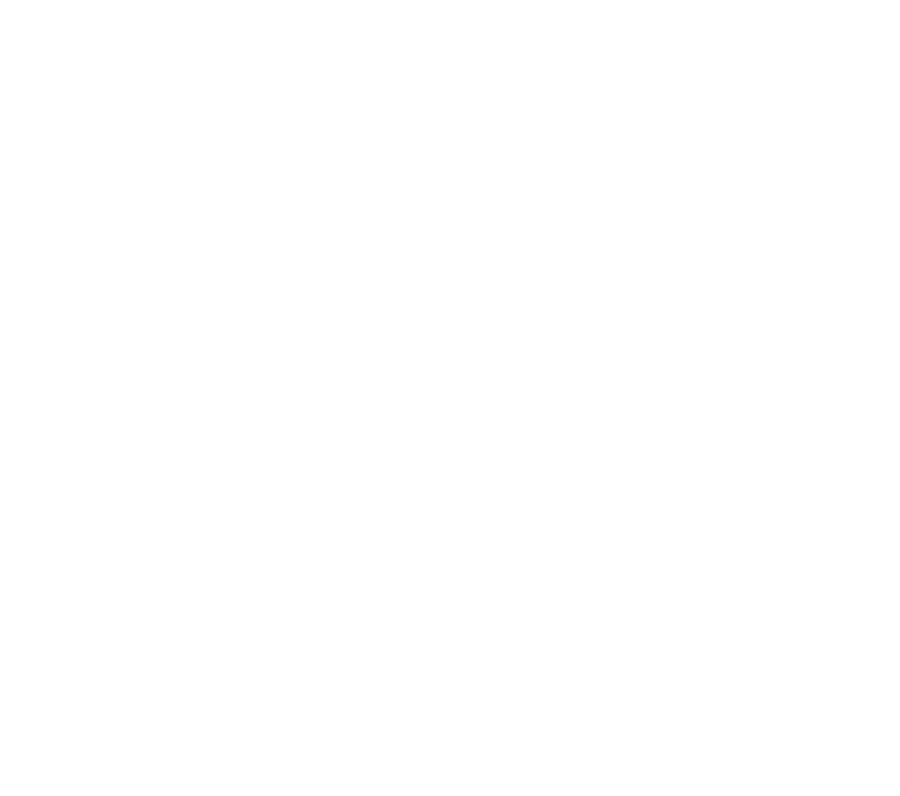

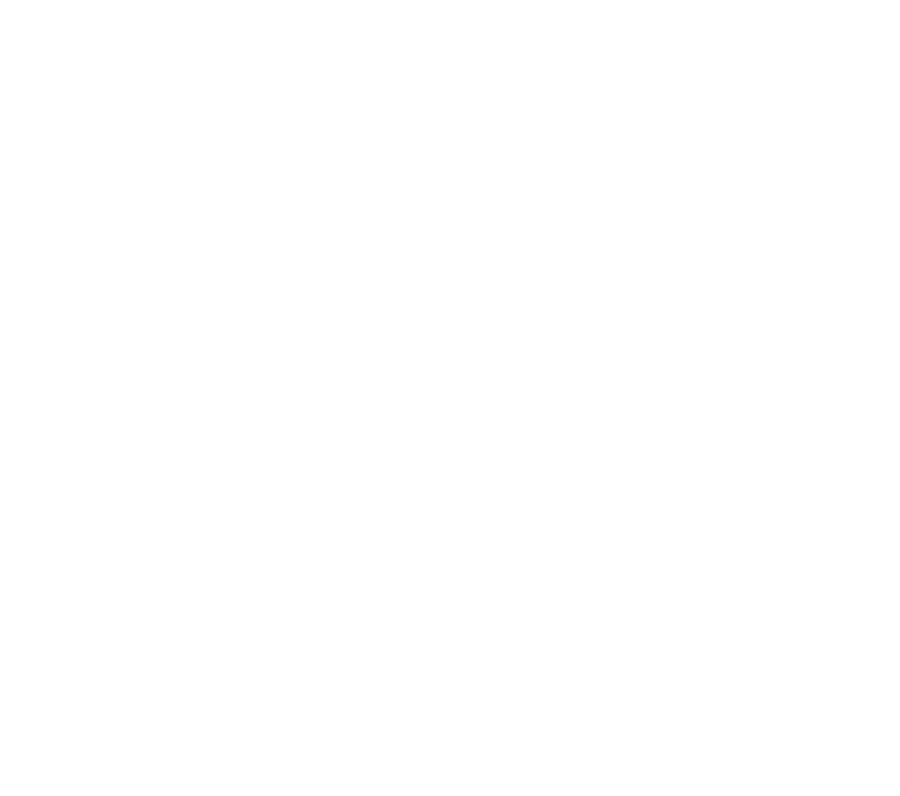

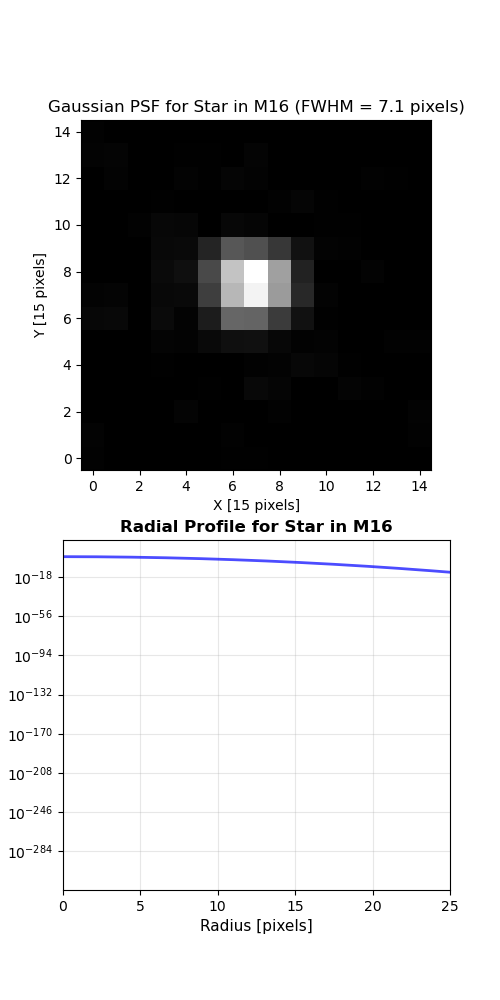

In [28]:
m16_cutout1 = ClusterAnalyzer(m16_file, m16_data, m16_hdu_list)
m16_cutout1.fit_star_psf(m16_data, 79.9, 950.5, 15, 40.0)

### Star 2

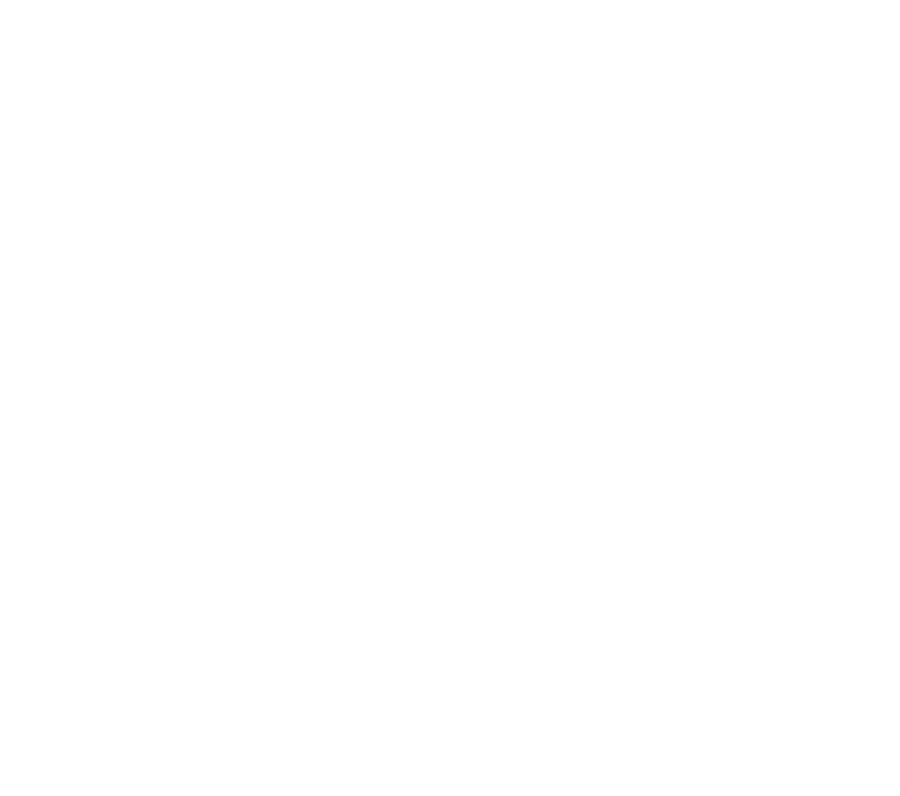

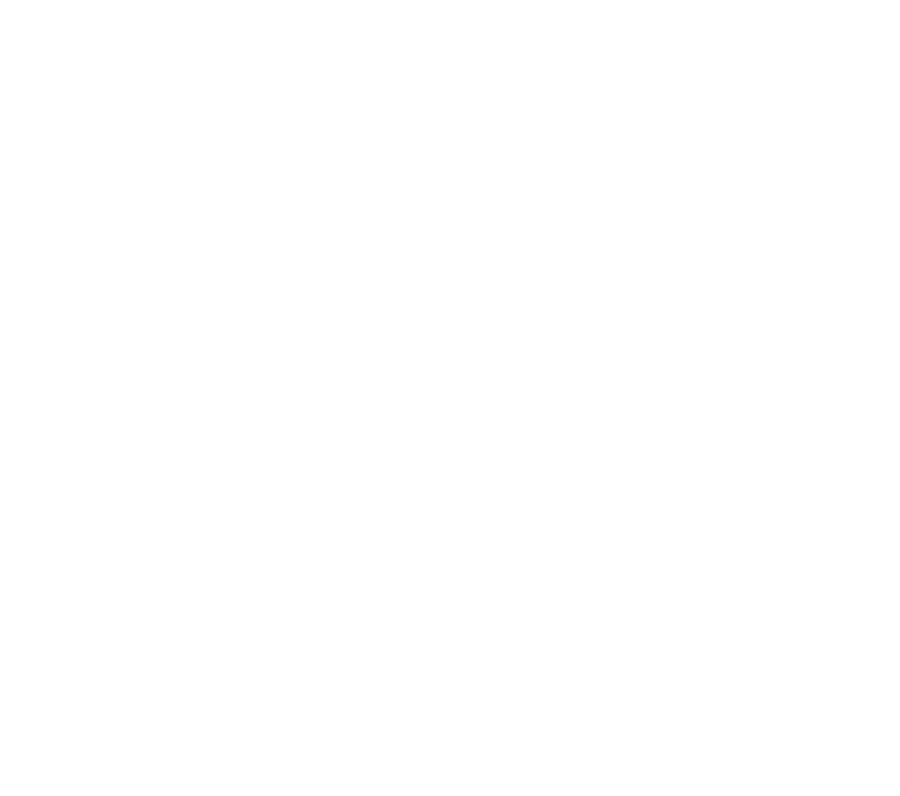

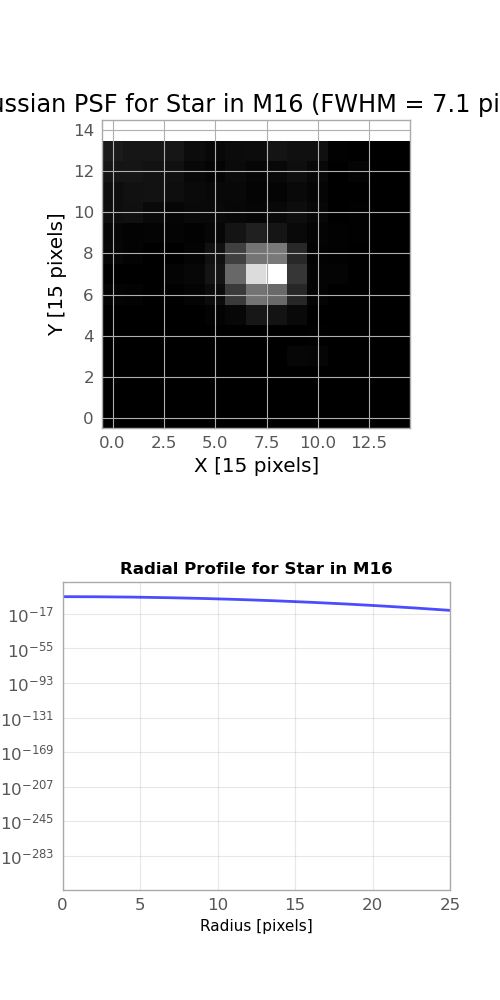

In [138]:
m16_cutout2 = ClusterAnalyzer(m16_file, m16_data, m16_hdu_list)
m16_cutout2.fit_star_psf(m16_data, 228.4, 951.0, 15, 118.9)

### Star 3

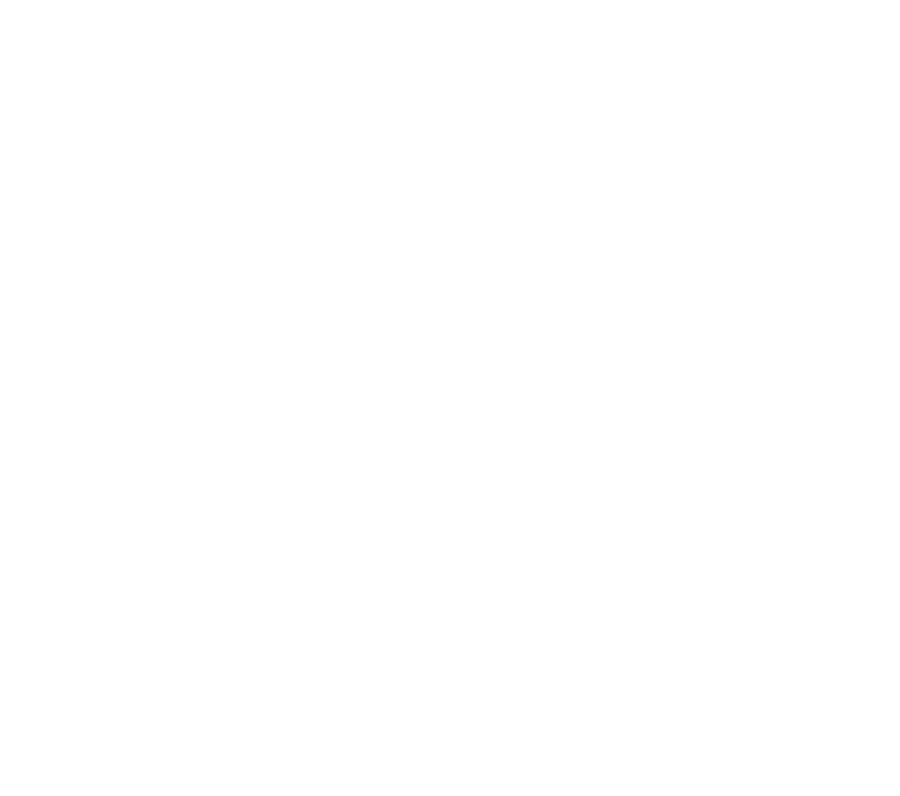

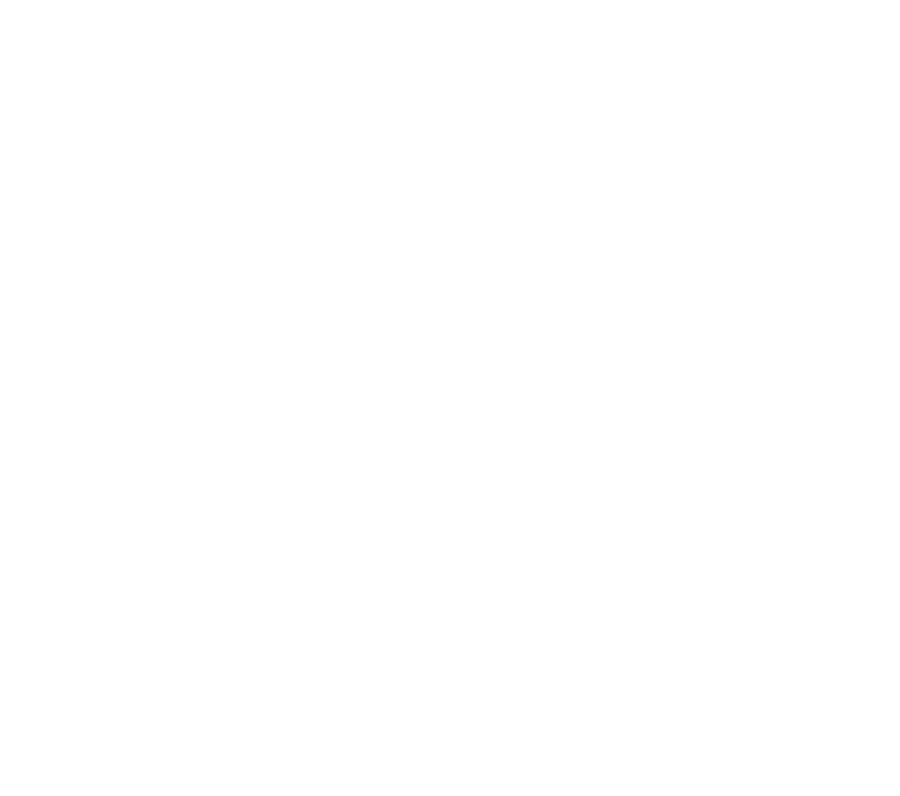

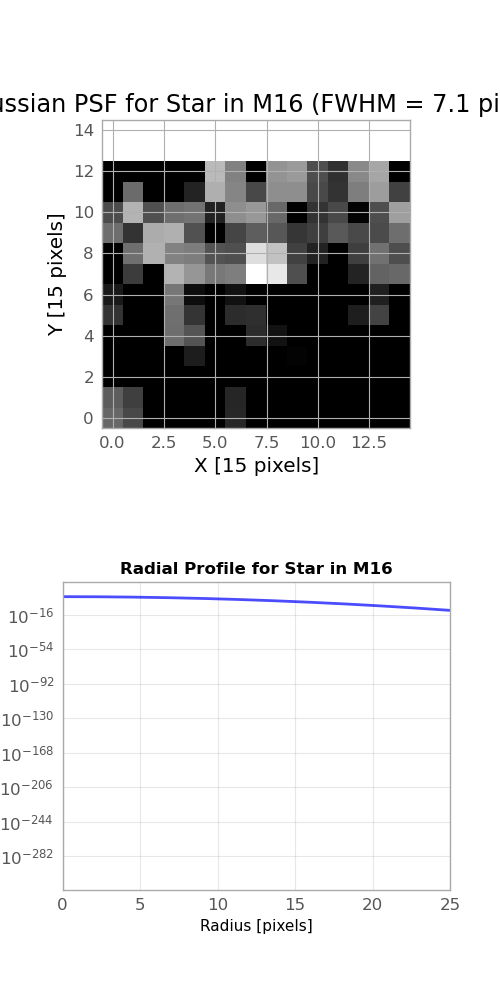

In [139]:
m16_cutout3 = ClusterAnalyzer(m16_file, m16_data, m16_hdu_list)
m16_cutout3.fit_star_psf(m16_data, 547.3, 951.3, 15, 5694.5)

### Star 4

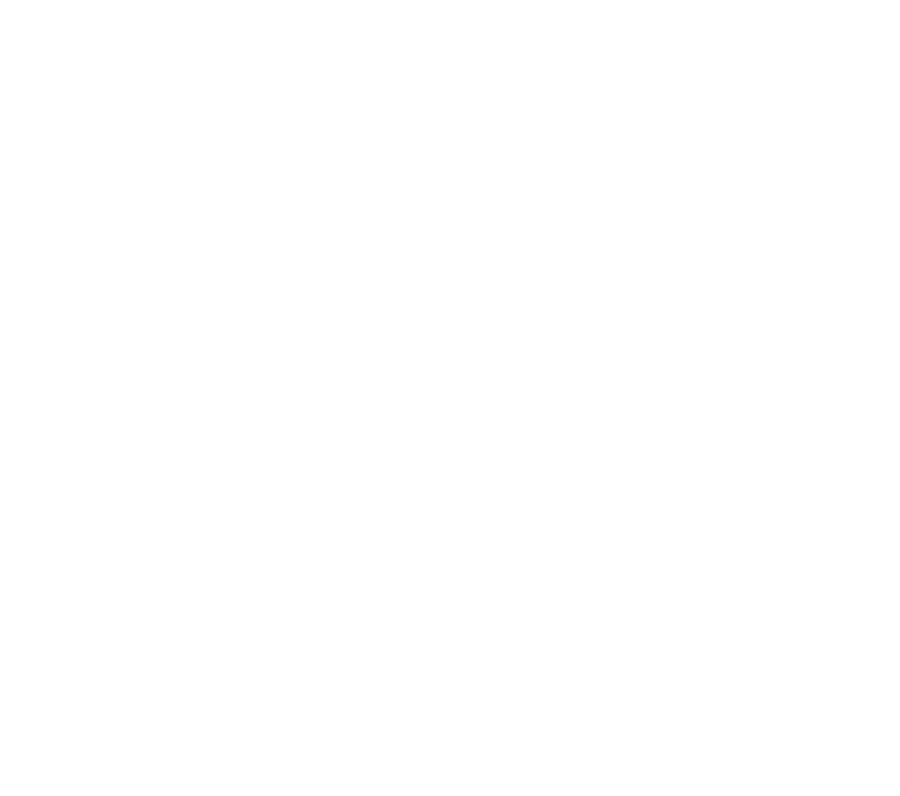

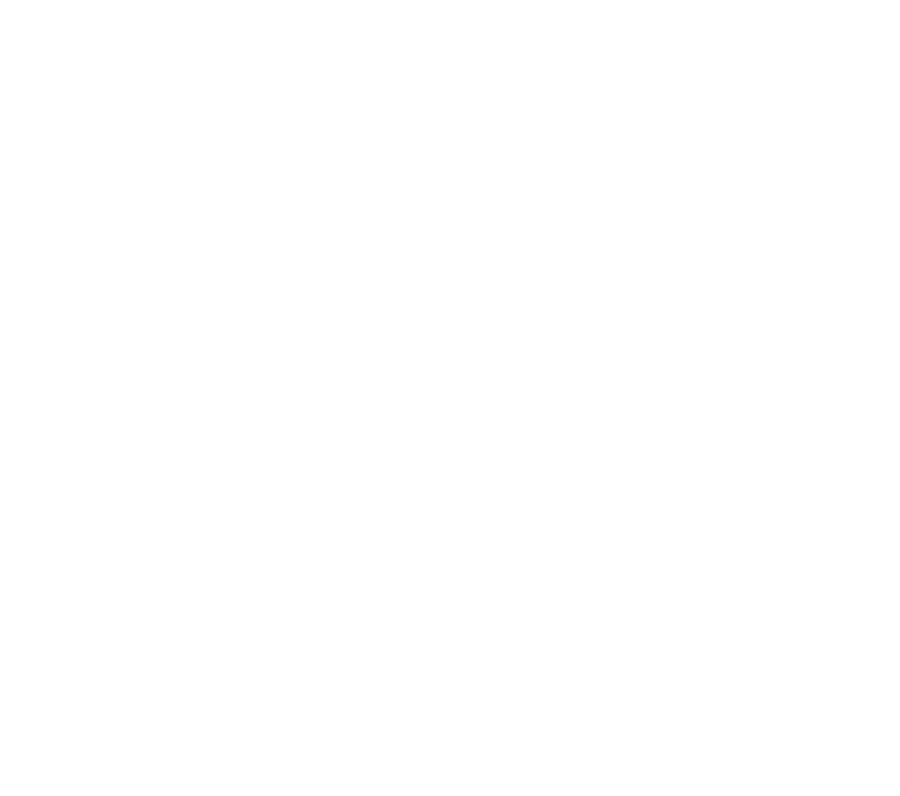

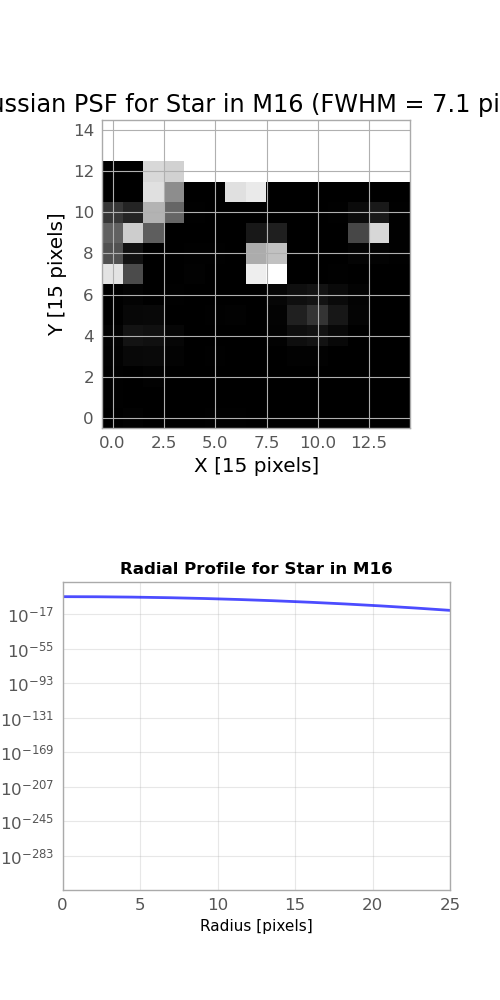

In [141]:
m16_cutout4 = ClusterAnalyzer(m16_file, m16_data, m16_hdu_list)
m16_cutout4.fit_star_psf(m16_data, 612.5, 951.2, 15, 263.8)

### Star 5

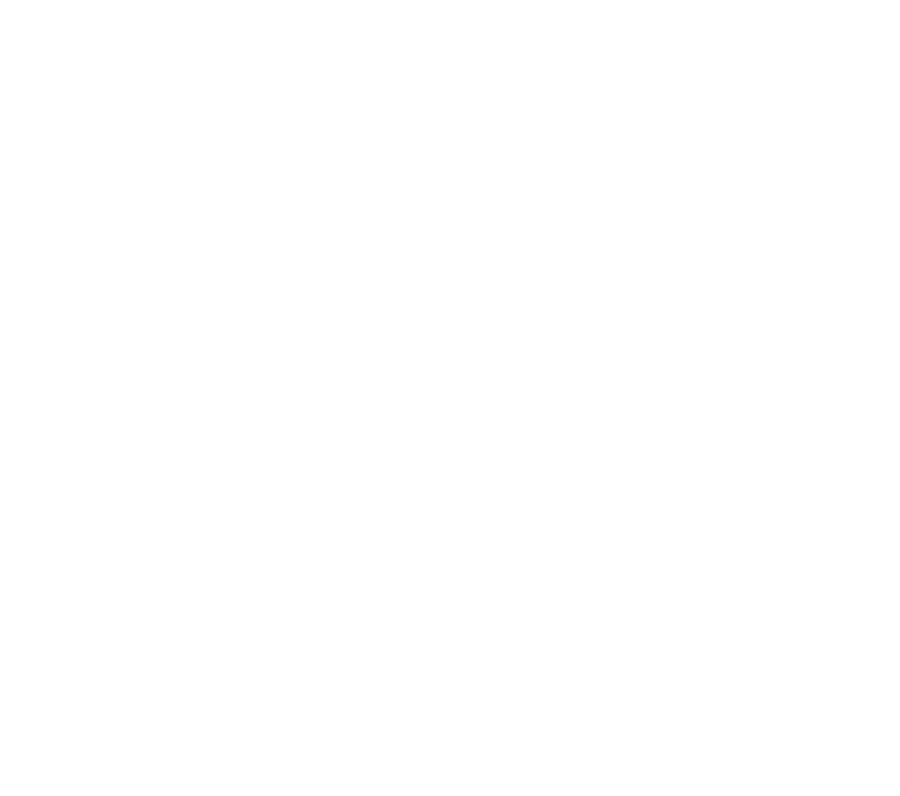

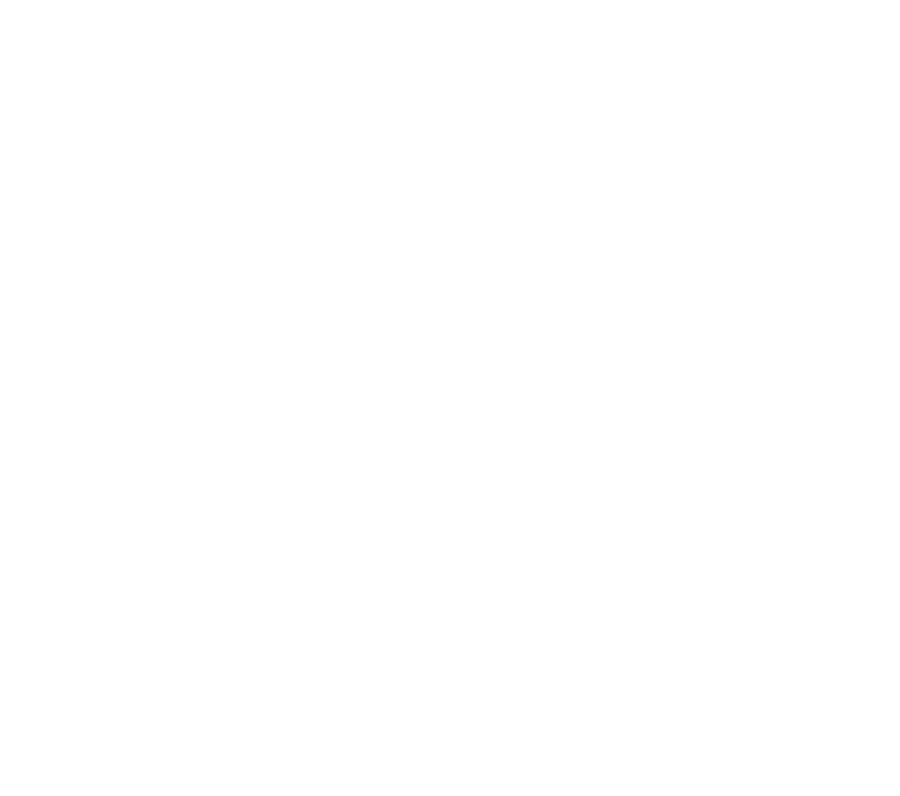

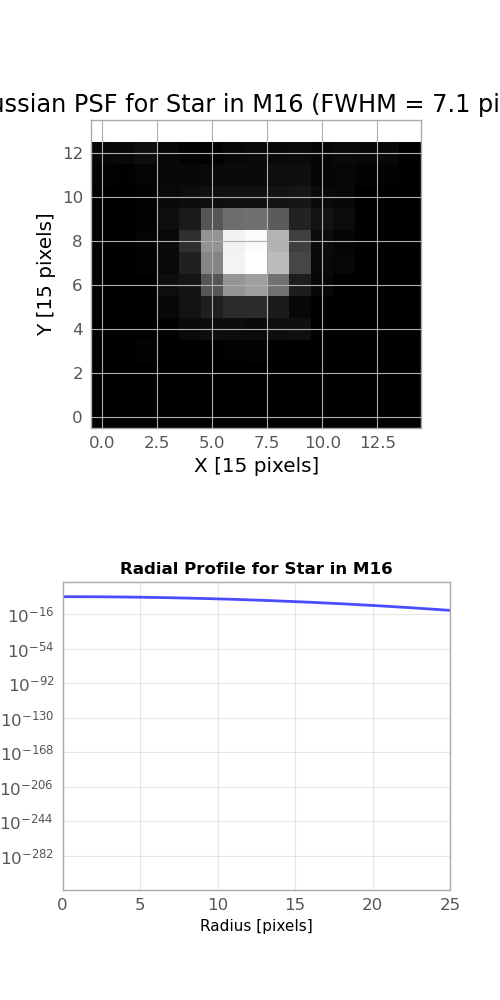

In [142]:
m16_cutout5 = ClusterAnalyzer(m16_file, m16_data, m16_hdu_list)
m16_cutout5.fit_star_psf(m16_data, 208.6, 952.4, 15, 2932.6)


### Star 6

In [ ]:
m16_cutout6 = ClusterAnalyzer(m16_file, m16_data, m16_hdu_list)
m16_cutout6.fit_star_psf(m16_data, 219, 132, 15, ___)

### Star 7

In [ ]:
m16_cutout7 = ClusterAnalyzer(m16_file, m16_data, m16_hdu_list)
m16_cutout7.fit_star_psf(m16_data, 219, 355, 15, ____)

### Star 8

In [ ]:
m16_cutout8 = ClusterAnalyzer(m16_file, m16_data, m16_hdu_list)
m16_cutout8.fit_star_psf(m16_data, 356, 127, 15, ___)

### Star 9

In [ ]:
m16_cutout9 = ClusterAnalyzer(m16_file, m16_data, m16_hdu_list)
m16_cutout9.fit_star_psf(m16_data, 790, 203, 15, ___)

### Star 10

In [ ]:
m16_cutout10 = ClusterAnalyzer(m16_file, m16_data, m16_hdu_list)
m16_cutout10.fit_star_psf(m16_data, 564, 10, 15, ___)


## Magnitude vs Position Diagram

In [29]:
import numpy as np
import matplotlib.image as mpimg

from astroquery.mast import Observations
from astroquery.mast import Catalogs
import pandas as pd
import astropy.io.fits as fits

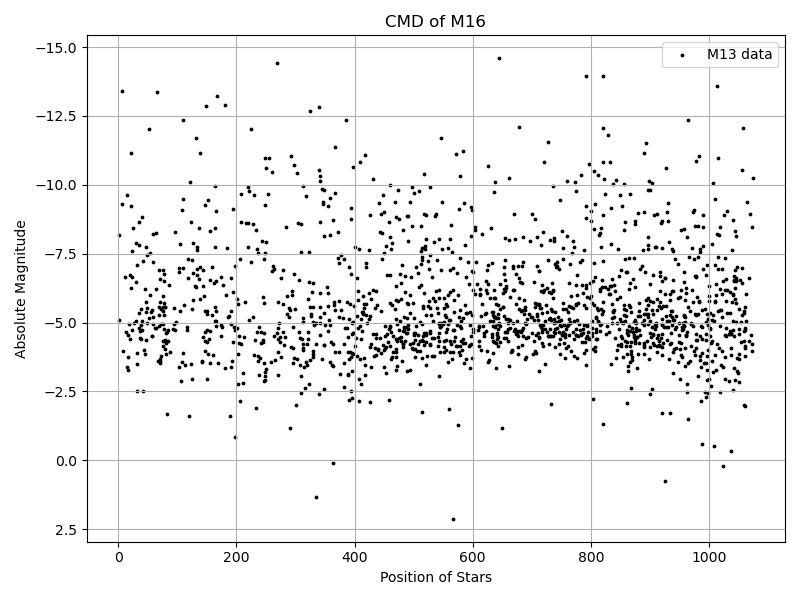

In [ ]:

magnitudesf1 = sources['mag'] #potential key for accessing magnitudes from HDU list

# Creating arrays for g-band and r-band magnitudes
#g_band = magnitudes[:, 1]
#r_band = magnitudes[:, 2]

# Calculating color (g - r)
#color_data1 = magnitudesf2 - magnitudesf1

# Plotting the CMD
plt.figure(figsize=(8, 6))
plt.scatter(sources['x_centroid'], sources['mag'], s=3, color="black", label="M13 data")
plt.ylim()
plt.gca().invert_yaxis()
plt.xlim()
plt.title("CMD of M16")
plt.ylabel("Absolute Magnitude")
plt.xlabel("Position of Stars")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Code Blocks for Reference 

In [ ]:
m16_image = ClusterAnalyzer(m16_file, m16_data, m16_hdu_list)
m16_image.show_image(m16_data, m16_file)

In [ ]:
m16_star_positions = ClusterAnalyzer(m16_file, m16_data, m16_hdu_list)
m16_star_positions.detect_star(m16_data)